# 02 — Statistical Analysis

Three simple, appropriate tests. Wording is careful: **associated with**, never *causes*.
This is observational hospital data — we test relationships, not causation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style="whitegrid")
p = Path("../data/processed/diabetes_clean.csv")
if not p.exists():
    p = Path("data/processed/diabetes_clean.csv")
df = pd.read_csv(p, keep_default_na=False)
print(df.shape, "| target rate %.2f%%" % (100*df.readmitted_30_days.mean()))

(101766, 39) | target rate 11.16%


## Test 1 — Is readmission associated with admission type?

- **Business question:** do emergency and elective pathways return at different rates?
- **H0:** readmission is independent of admission type.
- **H1:** readmission is associated with admission type.
- **Test:** Chi-square test of independence (two categoricals; large n, expected counts >> 5).

In [2]:
# Keep admission types with meaningful volume so expected counts stay large
top_adm = df["admission_type_id"].value_counts()
keep = top_adm[top_adm > 500].index
sub = df[df.admission_type_id.isin(keep)]
ct = pd.crosstab(sub["admission_type_id"], sub["readmitted_30_days"])
print(ct)
chi2, p, dof, exp = stats.chi2_contingency(ct)
print(f"\nChi2 = {chi2:.2f}, dof = {dof}, p-value = {p:.4f}")
print("Min expected count:", exp.min().round(1))

alpha = 0.05
print("Conclusion:", "Reject H0 — readmission IS associated with admission type."
      if p < alpha else "Fail to reject H0 — no evidence of association.")

readmitted_30_days      0     1
admission_type_id              
1                   47769  6221
2                   16414  2066
3                   16908  1961
5                    4290   495
6                    4705   586

Chi2 = 21.58, dof = 4, p-value = 0.0002
Min expected count: 534.5
Conclusion: Reject H0 — readmission IS associated with admission type.


**Conclusion (Test 1):** p < 0.05 → reject H0. Readmission is **associated with** admission type (emergency ~11.5% vs elective ~10.4%). Small gap, but with 100k rows it is statistically significant — significance ≠ large effect.

## Test 2 — Is readmission associated with discharge disposition?

- **Business question:** does where we discharge patients relate to returns?
- **H0:** readmission is independent of discharge group.
- **H1:** readmission is associated with discharge group.
- **Test:** Chi-square test of independence.

readmitted_30_days      0     1
dis_group                      
Care facility       13556  2397
Home                54632  5602
Home + health       11264  1638
Left AMA              533    90
Other/transfer       8044  1587

Chi2 = 744.16, dof = 4, p-value = 0.0000


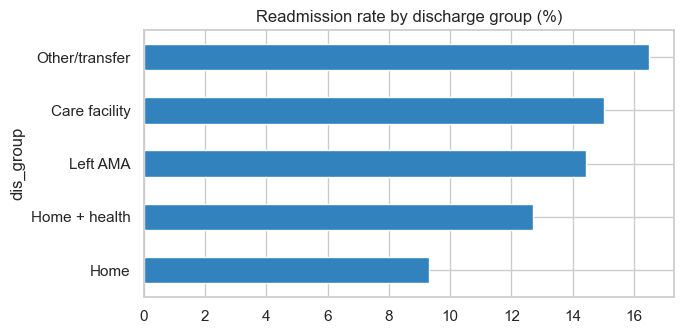

Conclusion: Reject H0 — readmission IS associated with discharge group.


In [3]:
import matplotlib.pyplot as plt

def discharge_group(i):
    if i == 1: return "Home"
    if i == 6: return "Home + health"
    if i in (3, 4, 5): return "Care facility"
    if i == 7: return "Left AMA"
    return "Other/transfer"

# Exclude expired/hospice (cannot be readmitted) — fairer comparison
d = df[~df.discharge_disposition_id.isin([11, 19, 20, 21, 13, 14])].copy()
d["dis_group"] = d["discharge_disposition_id"].map(discharge_group)
ct2 = pd.crosstab(d["dis_group"], d["readmitted_30_days"])
print(ct2)
chi2, p, dof, exp = stats.chi2_contingency(ct2)
print(f"\nChi2 = {chi2:.2f}, dof = {dof}, p-value = {p:.4f}")

rates = d.groupby("dis_group")["readmitted_30_days"].mean().mul(100).sort_values()
fig, ax = plt.subplots(figsize=(7, 3.5))
rates.plot.barh(ax=ax, color="#3182bd")
ax.set_title("Readmission rate by discharge group (%)")
plt.tight_layout(); plt.show()

print("Conclusion:", "Reject H0 — readmission IS associated with discharge group."
      if p < 0.05 else "Fail to reject H0.")

**Conclusion (Test 2):** p < 0.05 → reject H0. Discharge route is **associated with** readmission (facility/transfer ~15–16% vs home ~9%). Suggests discharge planning deserves review — not proof it causes returns.

## Test 3 — Does length of stay differ between readmitted and non-readmitted?

- **Business question:** do readmitted stays look different in length?
- **H0:** the stay-length distributions are the same for both groups.
- **H1:** the stay-length distributions differ.
- **Test:** Mann-Whitney U (stay days are discrete + right-skewed, so a t-test's normality assumption is shaky).

Skew readmitted: 0.98 | Skew not: 1.16
Median readmitted: 4.0 | Median not: 4.0


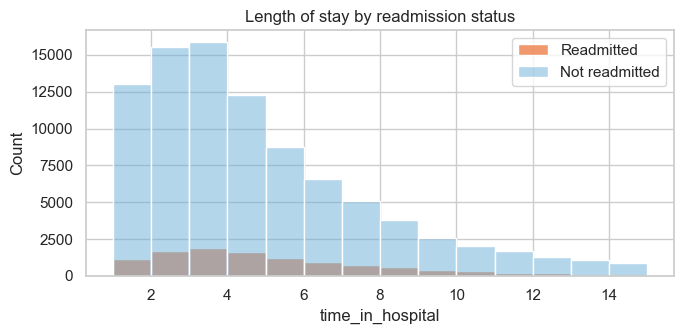

Mann-Whitney U = 560,893,881, p-value = 0.0000
Conclusion: Reject H0 — statistically significant difference in stay length.


In [4]:
a = df.loc[df.readmitted_30_days == 1, "time_in_hospital"]
b = df.loc[df.readmitted_30_days == 0, "time_in_hospital"]
print("Skew readmitted:", round(a.skew(), 2), "| Skew not:", round(b.skew(), 2))
print("Median readmitted:", a.median(), "| Median not:", b.median())

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.histplot(a, bins=range(1, 16), ax=ax, color="#e6550d", label="Readmitted", alpha=0.6)
sns.histplot(b, bins=range(1, 16), ax=ax, color="#6baed6", label="Not readmitted", alpha=0.5)
ax.set_title("Length of stay by readmission status")
ax.legend(); plt.tight_layout(); plt.show()

u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
print(f"Mann-Whitney U = {u:,.0f}, p-value = {p:.4f}")
print("Conclusion:", "Reject H0 — statistically significant difference in stay length."
      if p < 0.05 else "Fail to reject H0.")

**Conclusion (Test 3):** p < 0.05 → reject H0. There is a **statistically significant difference**: readmitted stays run ~0.4 days longer on average (4.77 vs 4.35). Real but modest — with 100k rows even small gaps test significant.

### Overall

| Test | Result |
|---|---|
| Admission type ↔ readmission (chi-square) | Significant association |
| Discharge group ↔ readmission (chi-square) | Significant association |
| Stay length by status (Mann-Whitney U) | Significant difference |

All three show *association*, not causation.